Notebook 2 - Volatility and Sharpe Ratio 

volatility = how much returns fluctuate = risk

sharpe ratio = return per unit risk

we import portfolio_returns from notebook 1 by rebuilding it here

In [4]:
# Block 1 : rebuilding Data from notebook 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'XOM']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

prices = yf.download(tickers, start = '2023-01-01', end = '2026-01-01', auto_adjust=True)['Close']
daily_returns = prices.pct_change().dropna()
portfolio_returns = daily_returns.dot(weights)

print("Data ready")
print(f"Date range: {daily_returns.index[0].date()} to {daily_returns.index[-1].date()}")       # print the first and last date in the dataset
print(f"Trading days: {len(daily_returns)}")

[*********************100%***********************]  5 of 5 completed

Data ready
Date range: 2023-01-04 to 2025-12-31
Trading days: 751


Volatility 

std of daily returns tells us how much returns bounce around each day 

multiply by root252 to annualise (252 trading days in a year)

higher volatility = higher risk

Annualised volatility per stock: 

 AAPL:  25.6%

 MSFT:  23.2%

 AMZN:  31.9%

 JPM:  23.1%

 XOM:  22.6%

 Portfolio:  17.0%


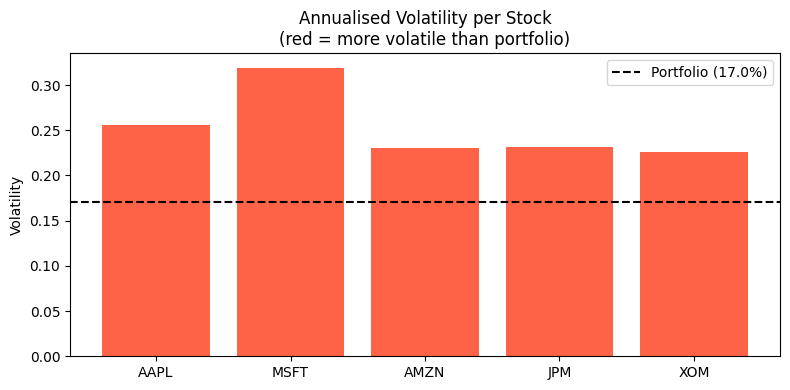

In [15]:
# Block 2 = Volatility 

volatility = daily_returns.std() * np.sqrt(252)

print("Annualised volatility per stock: ")
for ticker in tickers:
    print(f"\n {ticker}: {volatility[ticker]: .1%}")

# portfolio volatility
portfolio_vol = portfolio_returns.std() * np.sqrt(252)
print(f"\n Portfolio: {portfolio_vol: .1%}")

# plot volatility comparison
plt.figure(figsize=(8, 4))
colors = ['tomato' if v > portfolio_vol else 'steelblue' for v in volatility]
plt.bar (tickers, volatility, color = colors)
plt.axhline(y=portfolio_vol, color='black', linewidth=1.5,
            linestyle='--', label=f'Portfolio ({portfolio_vol:.1%})')
plt.title('Annualised Volatility per Stock\n(red = more volatile than portfolio)')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.savefig('../data/volatility.png', dpi=150)
plt.show()

Sharpe Ratio

measures return per unit of risk

higher = better risk adjusted performance

sharpe = (portfolio return - risk free rate) / volatility 

risk free rate = 4% (approximate US 10-year treasury yield)

anything above 1.0 is generally considered good

Annualised Portfolio Return     : 27.9%
Annualised Portfolio Volatility : 17.0%
Risk Free Rate                  : 4.0%

Portfolio Sharpe Ratio: 1.40

Sharpe Ratio per stock:
 AAPL:  1.01
 MSFT:  0.99
 AMZN:  1.07
 JPM:  1.31
 XOM:  0.27


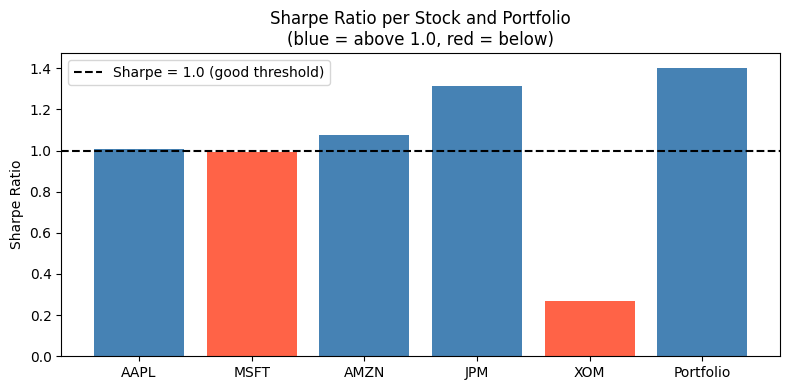

In [39]:
# Block 3: Sharpe Ratio

risk_free_rate = 0.04

# Annualised portfolio return
# mean daily return x 252 trading days = annual return
portfolio_annual_return = portfolio_returns.mean() * 252

print(f"Annualised Portfolio Return     : {portfolio_annual_return:.1%}")
print(f"Annualised Portfolio Volatility : {portfolio_vol:.1%}")
print(f"Risk Free Rate                  : {risk_free_rate:.1%}")

# Sharpe Ratio
sharpe  = (portfolio_annual_return - risk_free_rate) / portfolio_vol
print(f"\nPortfolio Sharpe Ratio: {sharpe:.2f}")


# Sharpe per indivisual stock
print("\nSharpe Ratio per stock:")
for ticker in tickers:
    stock_return = daily_returns[ticker].mean() * 252
    stock_vol = volatility[ticker]
    stock_sharpe = (stock_return - risk_free_rate) / stock_vol
    print(f" {ticker}: {stock_sharpe: .2f}")

# plot sharpe ratios
sharpe_values = {}

for ticker in tickers:
    stock_return = daily_returns[ticker].mean() * 252
    stock_vol = volatility[ticker]
    sharpe_values[ticker] = (stock_return - risk_free_rate) / stock_vol
sharpe_values['Portfolio'] = sharpe     # Add portfolio sharpe ratio

plt.figure(figsize=(8, 4))
colors = ['steelblue' if v >= 1 else 'tomato' for v in sharpe_values.values()]
plt.bar(sharpe_values.keys(), sharpe_values.values(), color=colors)

plt.axhline(y=1, color='black', linewidth=1.5,
            linestyle='--', label='Sharpe = 1.0 (good threshold)')
plt.axhline(y=0, color='grey', linewidth=0.5)
plt.title('Sharpe Ratio per Stock and Portfolio\n(blue = above 1.0, red = below)')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('../data/sharpe_ratio.png', dpi=150)
plt.show()

Volatility:
Portfolio at 17% is lower than most individual stocks — that's diversification working

1. JPM:  1.31  → best risk-adjusted return, surprising for a bank stock
2. AMZN: 1.07  → high return justified the volatility
3. AAPL: 1.01  → just above the good threshold
4. MSFT: 0.99  → just below, almost identical to AAPL
5. XOM:  0.27  → terrible, high risk low return
6. Portfolio: 1.40 → better than every individual stock